In [27]:

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

In [38]:
def draw(g: nx.Graph):
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    nx.draw(g, node_size=200, node_color='pink', with_labels=True, ax=ax)


In [45]:
edge_list = [
    ('A', 'B'),
    ('A', 'C'),
    ('C', 'B'),
    ('C', 'D'),
    ('I', 'D'),
    ('I', 'K'),
    ('K', 'J'),
    ('J', 'I'),
    ('D', 'E'),
    ('E', 'F'),
    ('F', 'G'),
    ('G', 'E'),
    ('E', 'H'),
]

g = nx.from_edgelist(edge_list)

In [58]:
g_new = g.copy()

In [65]:
betweeness = nx.edge_betweenness_centrality(g_new)

max_bet = max(betweeness.values())
edge_max_bet = [k for k, v in betweeness.items() if v == max_bet]

print(f"Max betweeness             : {max_bet:.4f}")
print(f"Edges having max betweeness: {edge_max_bet}")

Max betweeness             : 0.0545
Edges having max betweeness: [('E', 'H')]


In [66]:
for edge in edge_max_bet:
    g_new.remove_edge(*edge)

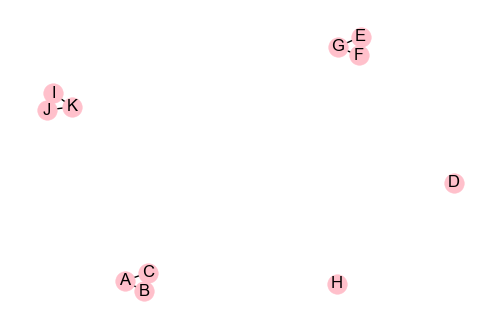

In [67]:
draw(g_new)

In [46]:
list(nx.community.girvan_newman(g))

[({'A', 'B', 'C', 'D', 'I', 'J', 'K'}, {'E', 'F', 'G', 'H'}),
 ({'A', 'B', 'C'}, {'D', 'I', 'J', 'K'}, {'E', 'F', 'G', 'H'}),
 ({'A', 'B', 'C'}, {'D'}, {'I', 'J', 'K'}, {'E', 'F', 'G', 'H'}),
 ({'A', 'B', 'C'}, {'D'}, {'I', 'J', 'K'}, {'E', 'F', 'G'}, {'H'}),
 ({'A'}, {'B', 'C'}, {'D'}, {'I', 'J', 'K'}, {'E', 'F', 'G'}, {'H'}),
 ({'A'}, {'B'}, {'C'}, {'D'}, {'I', 'J', 'K'}, {'E', 'F', 'G'}, {'H'}),
 ({'A'}, {'B'}, {'C'}, {'D'}, {'I'}, {'J', 'K'}, {'E', 'F', 'G'}, {'H'}),
 ({'A'}, {'B'}, {'C'}, {'D'}, {'I'}, {'K'}, {'J'}, {'E', 'F', 'G'}, {'H'}),
 ({'A'}, {'B'}, {'C'}, {'D'}, {'I'}, {'K'}, {'J'}, {'E'}, {'F', 'G'}, {'H'}),
 ({'A'}, {'B'}, {'C'}, {'D'}, {'I'}, {'K'}, {'J'}, {'E'}, {'F'}, {'G'}, {'H'})]